## Logistic Regression Model

In [1]:
# load liberaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Load cleaned data

In [2]:
# load the dataset
df = pd.read_csv('./data/Pakistani_Diabetes_Dataset_Cleaned.csv')
print(df.shape)
df.head()

(909, 18)


,Age,Gender,Weight_kg,BMI,Waist_inches,Systolic_BP,Diastolic_BP,Family_History,HbA1c_Level,Blood_Sugar_Random,Vision_Impact,Exercise_Duration,Polydipsia_Excessive_Thirst,Polyuria_Frequent_Urination,Diabetes_Duration_Years,Nephropathy_Kidney_Impact,HDL_Good_Cholesterol,Outcome
0,60.0,1,76.0,29.90,41.0,130,90,0,8.90,278,0,30,1,0,5.0,0,60,1
1,57.0,1,64.0,24.30,39.0,120,80,1,8.50,165,0,20,1,1,20.0,0,42,1
2,58.0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0.0,0,54,0
3,27.0,0,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0.0,0,57,0
4,56.0,1,70.0,25.80,43.0,125,90,0,8.30,139,1,40,1,0,5.0,1,53,1


### Import Model Libraries

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

### Seperate Feature and Target Columns

In [4]:
X = df.drop(columns=['Outcome'])

y = df['Outcome']

print("Feature Shape:" , X.shape)
print("Target Shape:" , y.shape)

Feature Shape: (909, 17)
Target Shape: (909,)


### Train, Test, Split

In [5]:
X_train, X_test , y_train, y_test = train_test_split(
    X,y , 
    test_size = 0.2 , 
    random_state = 42 , 
    stratify = y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (727, 17)
Test size: (182, 17)


### Scale Numerical Features

In [6]:
# select continues columns
cont_col = ['Age', 'Weight_kg', 'BMI', 'Waist_inches', 'Systolic_BP',
       'Diastolic_BP', 'HbA1c_Level', 'Blood_Sugar_Random',
        'Exercise_Duration', 'Diabetes_Duration_Years', 'HDL_Good_Cholesterol']
scaler = StandardScaler()

# fit and transform traing data(model learns here)
X_train[cont_col] = scaler.fit_transform(X_train[cont_col])

# only transform testing data
X_test[cont_col] = scaler.transform(X_test[cont_col])



### Train the Model

In [7]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train , y_train)
# print("Model Trained Successfully")


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### Check Prediction and Evaluation

In [8]:
y_pred = model.predict(X_test)


# evaluation
print("Accuracy:" , accuracy_score(y_test , y_pred))
print("Precision:" , precision_score(y_test , y_pred))
print("Recall:" , recall_score(y_test , y_pred))
print("F1 Score:" , f1_score(y_test , y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


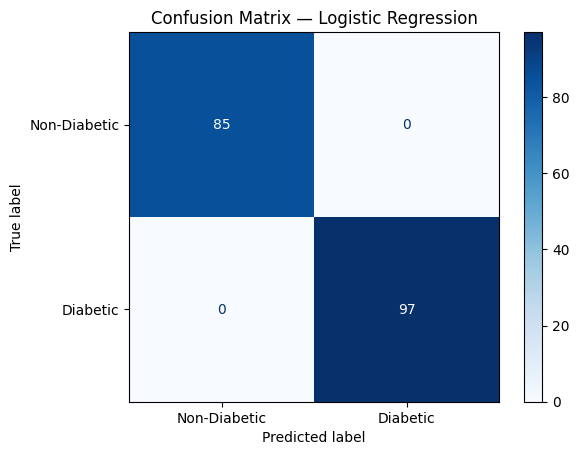

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.savefig('plots/confusion_matrix.png', bbox_inches='tight')
plt.show()

### Feature Imporatnce(Coefficients)

In [10]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

coef_df

,Feature,Coefficient
8,HbA1c_Level,3.070066
14,Diabetes_Duration_Years,2.399392
9,Blood_Sugar_Random,1.973168
12,Polydipsia_Excessive_Thirst,0.950979
0,Age,0.692333
5,Systolic_BP,0.635364
15,Nephropathy_Kidney_Impact,0.589082
13,Polyuria_Frequent_Urination,0.458157
3,BMI,0.319128
1,Gender,0.133328


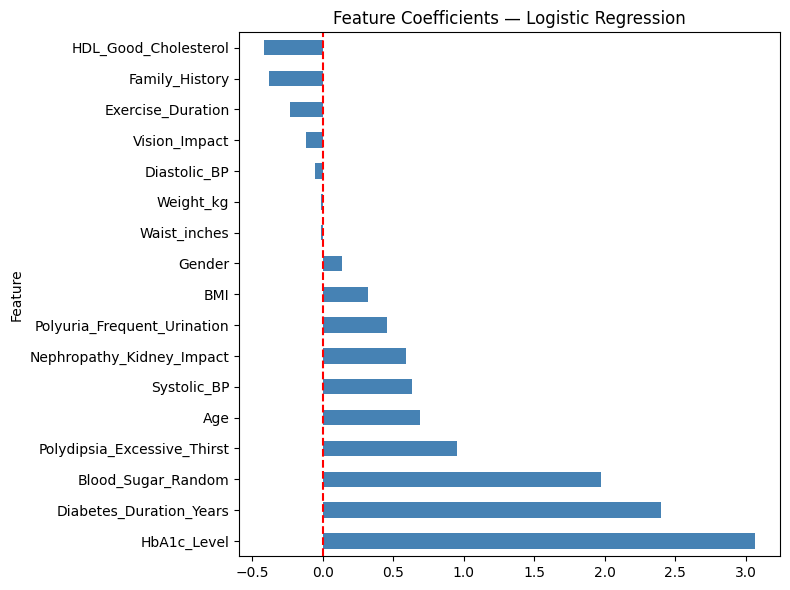

In [11]:
coef_df.plot(kind='barh', x='Feature', y='Coefficient', 
             figsize=(8,6), legend=False, color='steelblue')
plt.title('Feature Coefficients — Logistic Regression')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.savefig('plots/feature_coefficients.png', bbox_inches='tight')
plt.show()

## Model 1 - Results & Analysis

### Evaluation Scores
| Metric | Score |
|---|---|
| Accuracy | 1.0 (100%) |
| Precision | 1.0 |
| Recall | 1.0 |
| F1 Score | 1.0 |

A perfect score of 100% on all metrics looks impressive ,
but in machine learning, perfect scores are almost always
a red flag, not a success.

## ⚠ Problem Identified: Target Leakage

### What is Target Leakage?
Target leakage happens when your model is trained on features
that **already contain the answer** , features that would not
be available at the time of prediction in the real world.

### Leaky Features in This Model

| Feature | Why it's leaky |
|---|---|
| `HbA1c_Level` | This is a lab test used TO DIAGNOSE diabetes |
| `Blood_Sugar_Random` | Direct blood sugar measurement = diagnosis tool |
| `Diabetes_Duration_Years` | If someone has "5 years of diabetes" , they are already diabetic |
| `Nephropathy_Kidney_Impact` | Kidney damage is a complication of existing diabetes |
| `Vision_Impact` | Eye damage is a complication of existing diabetes |

The model did not "learn" diabetes — it simply read the diagnosis
from columns that already contained it. This is why accuracy is 100%.

### Coefficient Evidence
Looking at the feature coefficients:
- `HbA1c_Level` has the highest coefficient (3.07) - model relied on it most
- `Diabetes_Duration_Years` is second (2.39) - direct leakage
- `Blood_Sugar_Random` is third (1.97) - another diagnosis measurement

The model was essentially cheating.

## Real World Use Case - Who is this model for?

### The Problem
A person who already has HbA1c reports and blood sugar tests
done in a lab , already knows if they are diabetic.
Predicting diabetes for them is pointless.

### The Real User
In Pakistan, millions of people:
- Cannot afford lab tests (HbA1c costs Rs. 800–1500)
- Live far from clinics in smaller cities
- Have symptoms but are unsure , and delay getting tested

### The Solution
A home-based diabetes risk checker that uses only:
- Basic body measurements (age, weight, BMI, blood pressure)
- Lifestyle information (exercise)
- Symptoms they can observe themselves (excessive thirst, frequent urination)
- Family history (they already know this)

This model should answer: **"Based on what you feel and know
about your body , are you at risk of diabetes?"**
Not: "Given your lab reports , do you have diabetes?"

---
## Model 2 - Home User Diabetes Risk Predictor

### Selected Features (No Lab Tests Required)

| Feature | How a user knows this |
|---|---|
| Age | Knows their age |
| Gender | Knows their gender |
| Weight_kg | Home weighing scale |
| BMI | Calculated from weight and height |
| Systolic_BP | Basic BP machine (widely available) |
| Diastolic_BP | Same BP machine |
| Family_History | Knows if parents/siblings have diabetes |
| Exercise_Duration | Knows their daily exercise habits |
| Polydipsia_Excessive_Thirst | Observable symptom |
| Polyuria_Frequent_Urination | Observable symptom |

### Features Removed and Why
| Feature Removed | Reason |
|---|---|
| HbA1c_Level | Requires lab test |
| Blood_Sugar_Random | Requires glucometer or lab |
| Diabetes_Duration_Years | Already confirmed diabetic |
| Nephropathy_Kidney_Impact | Medical complication , already diagnosed |
| Vision_Impact | Medical complication , already diagnosed |
| HDL_Good_Cholesterol | Requires lab test |
| Waist_inches | Redundant with BMI and Weight |

In [12]:
# Model 2 — Home User Features Only
selected_features = ['Age', 'Gender', 'Weight_kg', 'BMI',
                     'Systolic_BP', 'Diastolic_BP', 'Family_History',
                     'Exercise_Duration', 'Polydipsia_Excessive_Thirst',
                     'Polyuria_Frequent_Urination']

X2 = df[selected_features]
y2 = df['Outcome']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

cont_col2 = ['Age', 'Weight_kg', 'BMI', 'Systolic_BP', 
             'Diastolic_BP', 'Exercise_Duration']

scaler2 = StandardScaler()
X2_train[cont_col2] = scaler2.fit_transform(X2_train[cont_col2])
X2_test[cont_col2] = scaler2.transform(X2_test[cont_col2])

model2 = LogisticRegression(max_iter=1000)
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

print("Model 2 , Home User Predictor Results:")
print("Accuracy :", round(accuracy_score(y2_test, y2_pred) , 4))
print("Precision:", round(precision_score(y2_test, y2_pred),4))
print("Recall   :", round(recall_score(y2_test, y2_pred) , 4))
print("F1 Score :", round(f1_score(y2_test, y2_pred) , 4))

Model 2 , Home User Predictor Results:
Accuracy : 0.9396
Precision: 0.93
Recall   : 0.9588
F1 Score : 0.9442


## Model 2 - Results & Interpretation

| Metric | Score |
|---|---|
| Accuracy | 93.96% |
| Precision | 93.00% |
| Recall | 95.88% |
| F1 Score | 94.42% |

### What these numbers mean
- Model correctly identifies 94 out of 100 patients
- When it predicts diabetic - it is right 93% of the time
- It catches 96% of actual diabetic patients - missing only 4%

### Why this model is more honest than Model 1
Model 1 scored 100% using lab test results that already
confirmed diabetes. Model 2 scores 94% using only symptoms
and basic measurements a person knows without any lab test.

94% with honest features > 100% with leaky features.

### Suitable For
Low-cost, home-based diabetes risk screening for people
who cannot afford lab tests but want to assess their risk
before visiting a doctor.

### Limitation
This model is a risk indicator - not a medical diagnosis.
Anyone flagged as high risk should consult a doctor
and get proper lab tests done.

### Confusion Matrix

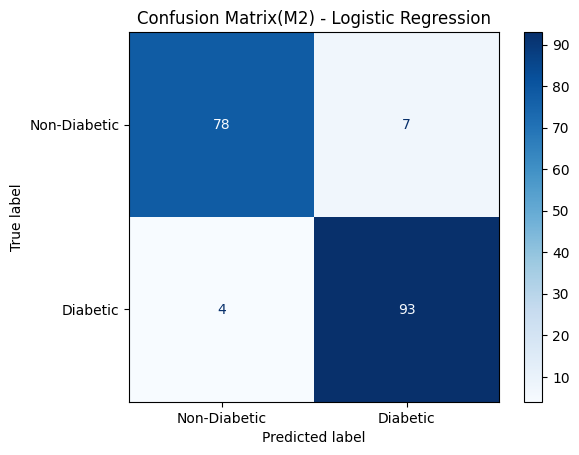

In [13]:
cm = confusion_matrix(y2_test, y2_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix(M2) - Logistic Regression')
plt.savefig('plots/confusion_matrix_m2.png', bbox_inches='tight')
plt.show()

### Feature Imporatnce(Coefficients)

In [14]:
coef_df2 = pd.DataFrame({
    'Feature': X2.columns,
    'Coefficient': model2.coef_[0]
}).sort_values('Coefficient', ascending=False)

coef_df2

,Feature,Coefficient
8,Polydipsia_Excessive_Thirst,2.469424
0,Age,2.027086
9,Polyuria_Frequent_Urination,1.659993
1,Gender,1.027118
6,Family_History,0.722559
4,Systolic_BP,0.632113
3,BMI,0.507997
2,Weight_kg,0.044214
5,Diastolic_BP,0.039476
7,Exercise_Duration,-0.233581


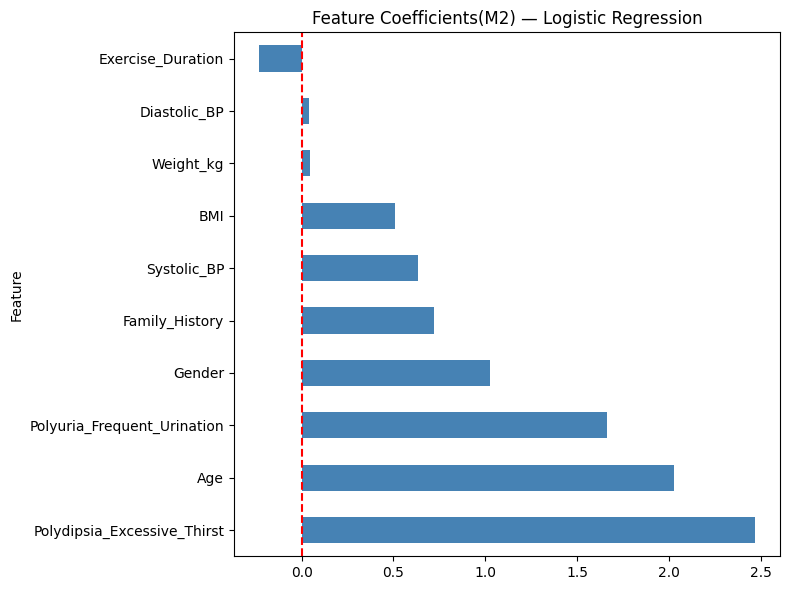

In [15]:
coef_df2.plot(kind='barh', x='Feature', y='Coefficient', 
             figsize=(8,6), legend=False, color='steelblue')
plt.title('Feature Coefficients(M2) — Logistic Regression')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.savefig('plots/feature_coefficients_m2.png', bbox_inches='tight')
plt.show()

## Model 2 - Feature Coefficients Analysis

### Top Positive Predictors (increase diabetes risk)
| Feature | Coefficient | Interpretation |
|---|---|---|
| Polydipsia_Excessive_Thirst | 2.47 | Strongest symptom signal , classic early warning |
| Age | 2.05 | Risk grows significantly with age |
| Polyuria_Frequent_Urination | 1.65 | Second strongest symptom |
| Gender | 1.03 | Males show higher risk in this dataset |
| Family_History | 0.68 | Genetic risk factor confirmed |
| Systolic_BP | 0.63 | High BP associated with diabetes |
| BMI | 0.49 | Higher BMI increases risk |

### Negative Predictors (decrease diabetes risk)
| Feature | Coefficient | Interpretation |
|---|---|---|
| Exercise_Duration | -0.32 | More exercise = lower risk - confirms EDA finding |
| Diastolic_BP | -0.07 | Minimal effect |
| Weight_kg | -0.05 | Redundant with BMI - near zero |

### Key Insight
- The two classic diabetes symptoms , excessive thirst and
frequent urination , are the model's strongest predictors.
This makes clinical sense and validates the model's logic.

- Exercise is the only lifestyle factor with a negative
coefficient , confirming that physical activity is
protective against diabetes in this dataset.

## Model Overview
This model is a Smart Diabetes Risk Calculator designed for everyday users. Instead of requiring complicated laboratory or hospital test results, it predicts the risk of diabetes using only basic lifestyle habits and common physical symptoms that anyone knows without visiting a clinic.

---
### Create Model Folder

In [16]:
import os
os.makedirs('model' , exist_ok=True)

### Save Model and Scaler

In [19]:
import joblib

# save model
joblib.dump(model2 , 'model/diabetes_model.joblib')

# save scaler
joblib.dump(scaler2 , 'model/diabetes_scaler.joblib')


['model/diabetes_scaler.joblib']

## Deployment


In [21]:
import streamlit as st
import joblib
import pandas as pd

# Page config
st.set_page_config(page_title="Diabetes Risk Calculator", layout="centered")

# Load model and scaler
@st.cache_resource
def load_artifacts():
    model = joblib.load("model/diabetes_model.joblib")
    scaler = joblib.load("model/diabetes_scaler.joblib")
    return model, scaler

try:
    model, scaler = load_artifacts()
except Exception as e:
    st.error("Model files could not be loaded. Please check model/ folder.")
    st.stop()

# UI Headers
st.title("🏥 Diabetes Risk Assessment Tool")
st.markdown("Fill out the form below to check your diabetes risk profile.")
st.write("---")

# User Inputs
col1, col2 = st.columns(2)

with col1:
    age = st.number_input("Age", min_value=1, max_value=120, value=30)
    gender = st.selectbox("Gender", options=["Male", "Female"])
    weight = st.number_input("Weight (kg)", min_value=10, max_value=200, value=70)
    bmi = st.number_input("BMI", min_value=10.0, max_value=60.0, value=22.0)
    systolic_bp = st.number_input("Systolic BP (e.g. 120)", min_value=70, max_value=250, value=120)

with col2:
    diastolic_bp = st.number_input("Diastolic BP (e.g. 80)", min_value=40, max_value=150, value=80)
    family_history = st.selectbox("Family History of Diabetes?", options=["No", "Yes"])
    exercise = st.number_input("Daily Exercise (minutes)", min_value=0, max_value=180, value=0)
    polydipsia = st.selectbox("Excessive Thirst?", options=["No", "Yes"])
    polyuria = st.selectbox("Frequent Urination?", options=["No", "Yes"])

st.write("---")

# Prediction
if st.button("Calculate Risk Score", type="primary"):

    # Encode categoricals
    gender_enc = 1 if gender == "Male" else 0
    fam_enc = 1 if family_history == "Yes" else 0
    thirst_enc = 1 if polydipsia == "Yes" else 0
    urine_enc = 1 if polyuria == "Yes" else 0

    # Build DataFrame — exact column order matching X_train
    input_data = pd.DataFrame([{
        'Age': age,
        'Gender': gender_enc,
        'Weight_kg': weight,
        'BMI': bmi,
        'Systolic_BP': systolic_bp,
        'Diastolic_BP': diastolic_bp,
        'Family_History': fam_enc,
        'Exercise_Duration': exercise,
        'Polydipsia_Excessive_Thirst': thirst_enc,
        'Polyuria_Frequent_Urination': urine_enc
    }])

    # Scale continuous columns — same list used during training
    cont_cols = ['Age', 'Weight_kg', 'BMI', 'Systolic_BP', 
                 'Diastolic_BP', 'Exercise_Duration']
    input_data[cont_cols] = scaler.transform(input_data[cont_cols])

    # Predict
    prediction = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1] * 100

    # Show result
    if prediction == 1:
        st.error(f"⚠️ **High Risk Detected ({prob:.1f}%)**")
        st.write("Your symptoms suggest a higher probability of diabetes. Please consult a doctor for an HbA1c test.")
    else:
        st.success(f"✅ **Low Risk ({prob:.1f}%)**")
        st.write("Your indicators look stable. Maintain a balanced diet and regular physical activity.")

st.write("---")
st.caption("⚠ This is a risk indicator only — not a medical diagnosis.")

ModuleNotFoundError: No module named 'streamlit'

In [22]:
import sys
print(sys.executable)

c:\Users\HP\miniconda3\envs\python_ml\python.exe
